In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

#set style for better looking charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(10,6)
#load your cleaned data
df = pd.read_csv('telco_cleaned.csv')

print("Data Load Successfully!")
print(f"Shape: {df.shape}")
print(df.head())


Data Load Successfully!
Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Stream

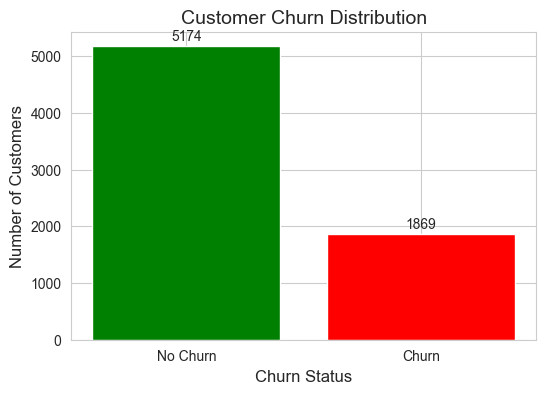

📊 Overall Churn Rate: 26.5%
Customers who stayed: 5174
Customers who churned: 1869


In [20]:
# Churn distribution chart
plt.figure(figsize=(6, 4))

churn_counts = df['Churn'].value_counts().sort_index()

bars = plt.bar([0, 1], churn_counts.values, color=['green', 'red'])
plt.title('Customer Churn Distribution', fontsize=14)
plt.ylabel('Number of Customers', fontsize=12)
plt.xlabel('Churn Status', fontsize=12)
plt.xticks([0, 1], ['No Churn', 'Churn'])

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom')

plt.show()

churn_rate = df['Churn'].mean() * 100
print(f"📊 Overall Churn Rate: {churn_rate:.1f}%")
print(f"Customers who stayed: {churn_counts[0]}")
print(f"Customers who churned: {churn_counts[1]}")

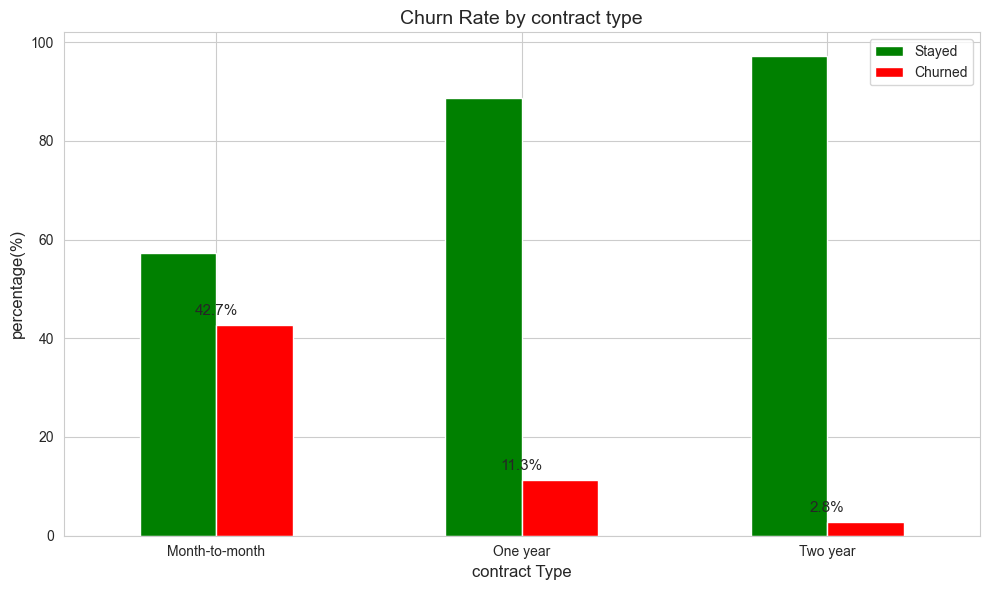


🔍 Key Insight:
Month-to-month contracts: 42.7% churn
One year contracts: 11.3% churn
Two year contracts: 2.8% churn


In [23]:
#create cross tabulation
contract_churn = pd.crosstab(df['Contract'],df['Churn'], normalize='index')*100

#plot
ax = contract_churn.plot(kind='bar', color=['green', 'red'], figsize=(10, 6))
plt.title('Churn Rate by contract type',fontsize=14)
plt.xlabel('contract Type',fontsize=12)
plt.ylabel('percentage(%)', fontsize=12)
plt.legend(['Stayed','Churned'],loc='upper right')
plt.xticks(rotation=0)


# Add percentage labels on bars
for i, contract in enumerate(contract_churn.index):
    churn_pct = contract_churn.iloc[i, 1]
    plt.text(i, churn_pct + 2, f'{churn_pct:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print("\n🔍 Key Insight:")
print(f"Month-to-month contracts: {contract_churn.iloc[0, 1]:.1f}% churn")
print(f"One year contracts: {contract_churn.iloc[1, 1]:.1f}% churn")
print(f"Two year contracts: {contract_churn.iloc[2, 1]:.1f}% churn")

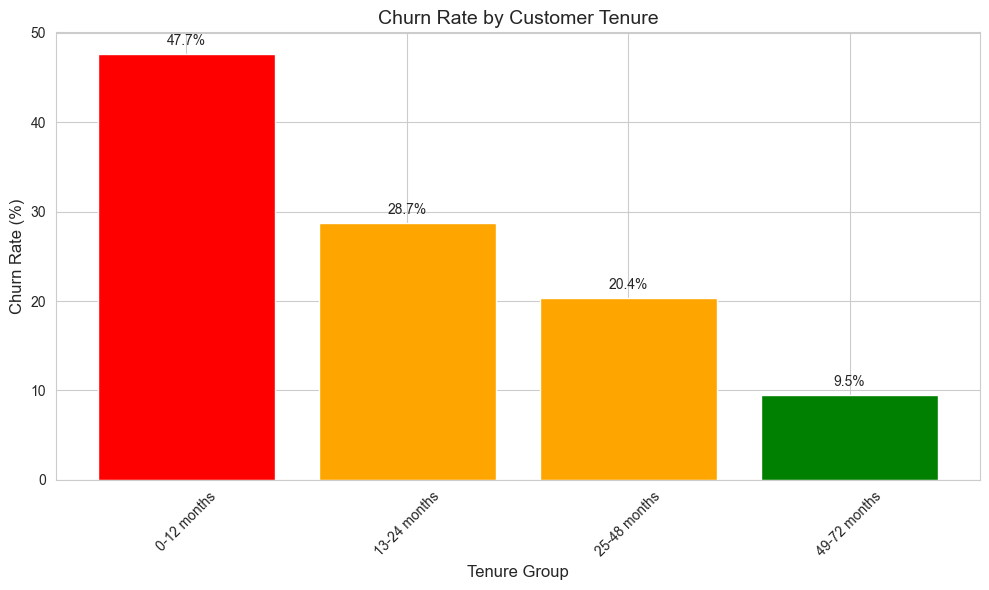


🔍 Key Insight:
New customers (first year): 47.7% churn
Loyal customers (6+ years): 9.5% churn


In [24]:
# Create tenure groups
df['tenure_group'] = pd.cut(df['tenure'], 
                              bins=[0, 12, 24, 48, 72, 100],
                              labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months', '73+ months'])

# Calculate churn rate by tenure group
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].mean() * 100

# Plot
plt.figure(figsize=(10, 6))
colors = ['red', 'orange', 'orange', 'green', 'green']
bars = plt.bar(tenure_churn.index, tenure_churn.values, color=colors)
plt.title('Churn Rate by Customer Tenure', fontsize=14)
plt.xlabel('Tenure Group', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=45)

# Add labels
for bar, rate in zip(bars, tenure_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, 
             f'{rate:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n🔍 Key Insight:")
print(f"New customers (first year): {tenure_churn.iloc[0]:.1f}% churn")
print(f"Loyal customers (6+ years): {tenure_churn.iloc[-1]:.1f}% churn")

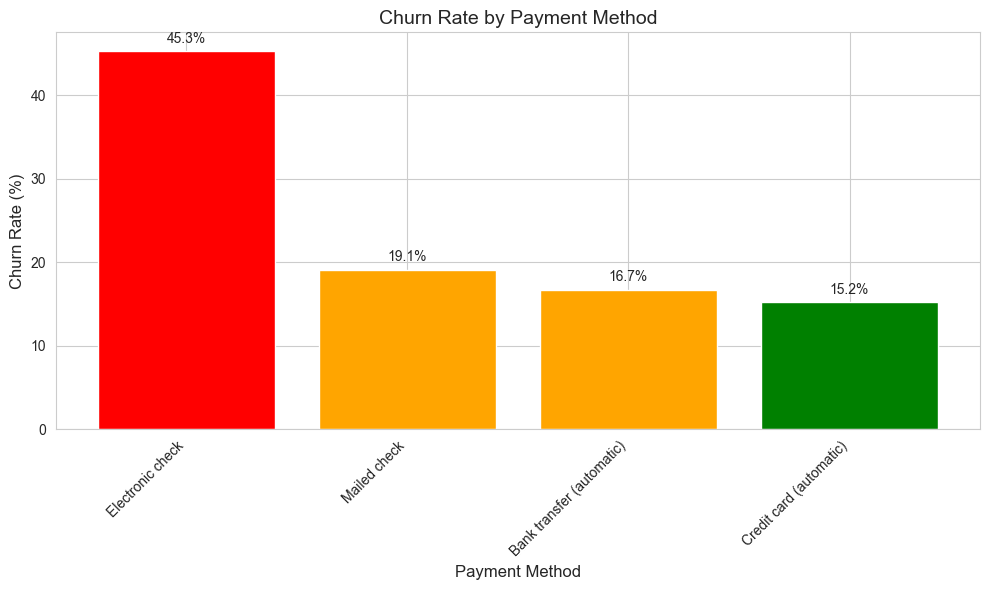


🔍 Key Insight:
Highest churn: Electronic check - 45.3%
Lowest churn: Credit card (automatic) - 15.2%


In [25]:
# Calculate churn rate by payment method
payment_churn = df.groupby('PaymentMethod')['Churn'].mean() * 100
payment_churn = payment_churn.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
colors = ['red', 'orange', 'orange', 'green']
bars = plt.bar(payment_churn.index, payment_churn.values, color=colors)
plt.title('Churn Rate by Payment Method', fontsize=14)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add labels
for bar, rate in zip(bars, payment_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, 
             f'{rate:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n🔍 Key Insight:")
print(f"Highest churn: {payment_churn.index[0]} - {payment_churn.iloc[0]:.1f}%")
print(f"Lowest churn: {payment_churn.index[-1]} - {payment_churn.iloc[-1]:.1f}%")

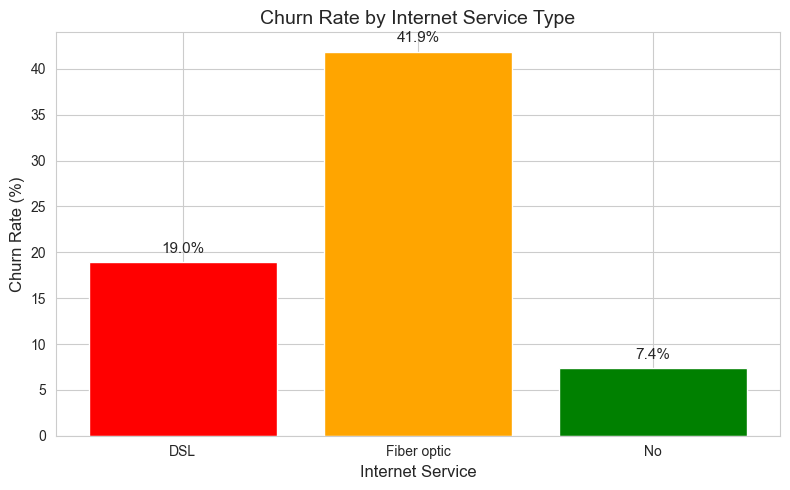


🔍 Key Insight:
Fiber optic: 41.9% churn
DSL: 19.0% churn
No internet: 7.4% churn


In [26]:
# Calculate churn rate by internet service
internet_churn = df.groupby('InternetService')['Churn'].mean() * 100

# Plot
plt.figure(figsize=(8, 5))
colors = ['red', 'orange', 'green']
bars = plt.bar(internet_churn.index, internet_churn.values, color=colors)
plt.title('Churn Rate by Internet Service Type', fontsize=14)
plt.xlabel('Internet Service', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=0)

# Add labels
for bar, rate in zip(bars, internet_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, 
             f'{rate:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print("\n🔍 Key Insight:")
print(f"Fiber optic: {internet_churn.get('Fiber optic', 0):.1f}% churn")
print(f"DSL: {internet_churn.get('DSL', 0):.1f}% churn")
print(f"No internet: {internet_churn.get('No', 0):.1f}% churn")

In [15]:
# DIAGNOSTIC CELL - Check your data first

# Check if Churn column exists
print("Column names:")
print(df.columns.tolist())

print("\n" + "="*50)

# Check Churn column values
if 'Churn' in df.columns:
    print("\nChurn column unique values:")
    print(df['Churn'].unique())
    
    print("\nChurn value counts:")
    print(df['Churn'].value_counts())
    
    print("\nChurn data type:")
    print(df['Churn'].dtype)
else:
    print("\n❌ 'Churn' column NOT found!")
    print("Looking for similar column names...")
    for col in df.columns:
        if 'churn' in col.lower():
            print(f"  Found: {col}")

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


Churn column unique values:
[nan]

Churn value counts:
Series([], Name: count, dtype: int64)

Churn data type:
float64


In [18]:
# Load the ORIGINAL file again (with correct filename)
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')  # Added underscore after UseC_

print("Original data loaded!")
print(f"Shape: {df.shape}")
print("\nFirst 3 rows of original Churn column:")
print(df['Churn'].head(3))

# Clean the data properly
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert Churn from Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("\n" + "="*50)
print("After cleaning:")
print(f"Churn unique values: {df['Churn'].unique()}")
print(f"Churn value counts:")
print(df['Churn'].value_counts())
print(f"Churn data type: {df['Churn'].dtype}")

# Save it correctly (overwrite the bad one)
df.to_csv('telco_cleaned.csv', index=False)
print("\n✅ telco_cleaned.csv has been saved correctly!")

Original data loaded!
Shape: (7043, 21)

First 3 rows of original Churn column:
0     No
1     No
2    Yes
Name: Churn, dtype: str

After cleaning:
Churn unique values: [0 1]
Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn data type: int64

✅ telco_cleaned.csv has been saved correctly!


C:\Users\user\AppData\Local\Temp\ipykernel_7792\906868125.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [19]:
# Verify the file saved correctly
df_test = pd.read_csv('telco_cleaned.csv')
print("Verifying reloaded file:")
print(f"Churn column unique values: {df_test['Churn'].unique()}")
print(f"Churn value counts:")
print(df_test['Churn'].value_counts())

Verifying reloaded file:
Churn column unique values: [0 1]
Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [17]:
import os

# List all files in current directory
print("Files in current folder:")
print(os.listdir())

# Look for CSV files specifically
csv_files = [f for f in os.listdir() if f.endswith('.csv')]
print("\nCSV files found:")
for file in csv_files:
    print(f"  - {file}")

Files in current folder:
['.venv', '01_data_cleaning.ipynb', '02_eda_churn.ipynb', 'telco_cleaned.csv', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']

CSV files found:
  - telco_cleaned.csv
  - WA_Fn-UseC_-Telco-Customer-Churn.csv
